#Training for TNF-LPS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import os




#Bar plots for TNF-LPS

In [2]:
# Set to 1 to automatically download files, 0 to not download
fig_save_path = "/Users/xiaoluguo/Documents/Postdoc_projects/Projects/Ongoing_combinatorial_ligand/subfigures2025/revision/figure4/"

def save_and_download(filename, download=False, formats=None):
    if formats is None:
        formats = ['pdf']

    saved_files = []
    for fmt in formats:
        filepath = f"{filename}.{fmt}"
        plt.savefig(filepath, bbox_inches='tight', dpi=300)
        saved_files.append(filepath)

    if download and auto_download:
        for file in saved_files:
            files.download(file)  # Trigger each file separately

def print_metric_values(metric_values, metric_name, label_mapping, subset_labels_plot):
    """
    Print metric values class by class.
    """
    print("\n" + "=" * 60)
    print(metric_name)
    print("=" * 60)

    for idx, value in zip(subset_labels_plot, metric_values):
        label_name = label_mapping[idx]
        print(f"{idx}\t{label_name}\t{value:.4f}")

    print("=" * 60 + "\n")
    
# Recall Bar Plot
def plot_sensitivity_B(data_to_plot, data_label, label_mapping, with_labels=True):
    if with_labels:
        plt.figure(figsize=(22, 12))
        num_classes = len(data_to_plot)
        colors = sns.color_palette("Blues_r", n_colors=num_classes)

        subset_labels_plot = sorted(label_mapping.keys())
        bars = plt.bar(range(num_classes), data_to_plot, color=colors)

        plt.title("True Positive Predictions for" + data_label + "conditions using Sensitivity")
        plt.xlabel("Predicted Ligand")
        plt.ylabel("True Positive")
        plt.ylim(0, 1)
        plt.xticks(range(num_classes), [label_mapping[i] for i in subset_labels_plot], rotation=45, ha='right')
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=8)
        save_and_download(fig_save_path + "sensitivity_LABELbarplot_" + data_label, download=True, formats=['pdf'])
    else:
        plt.figure(figsize=(80/72, 50/72))
        plt.bar(range(len(data_to_plot)), data_to_plot, color=sns.color_palette("Blues_r", n_colors=len( data_to_plot)))
        plt.ylim(0, 1)
        plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xticks(range(len( data_to_plot)))
        plt.gca().set_xticklabels([])
        save_and_download(fig_save_path + "sensitivity_barplot_" + data_label, download=True, formats=['pdf'])

    plt.show()

# Precision Bar Plot
def plot_precision_B(data_to_plot, data_label, label_mapping, with_labels=True):
    subset_labels_plot = sorted(label_mapping.keys())
    if with_labels:
        plt.figure(figsize=(22, 12))
        num_classes = len(data_to_plot)
        colors = sns.color_palette("Reds_r", n_colors=num_classes)

        bars = plt.bar(range(num_classes), data_to_plot, color=colors)

        plt.title("True Positive Predictions for TNF, LPS, TNF_LPS conditions using Precision")
        plt.xlabel("Predicted Ligand")
        plt.ylabel("Precision")
        plt.ylim(0, 1)
        plt.xticks(range(num_classes), [label_mapping[i] for i in subset_labels_plot], rotation=45, ha='right')
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=8)
        save_and_download(fig_save_path + "precision_LABELbarplot_" + data_label, download=True, formats=['pdf'])
    else:
        plt.figure(figsize=(80/72, 50/72))
        plt.bar(range(len(data_to_plot)), data_to_plot, color=sns.color_palette("Reds_r", n_colors=len( data_to_plot)))
        plt.ylim(0, 1)
        plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xticks(range(len( data_to_plot)))
        plt.gca().set_xticklabels([])
        save_and_download(fig_save_path + "precision_barplot_" + data_label, download=True, formats=['pdf'])

    plt.show()

def RandomForestClassifier_plot_PairLigand(subset_labels_B,label_mapping_B, data_label ):
    subset_labels_plot = sorted(label_mapping_B.keys())
    # Load the data
    X = pd.read_csv('Comb_ligands_31conditions_X_codon_202604.csv', header=None)
    y = pd.read_csv('Comb_ligands_31conditions_y_codon_202604.csv', header=None)
    
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    
    mask_B = y[0].isin(subset_labels_B)  # Create a mask for filtering
    
    # Extract the subset
    X_B = X[mask_B]
    y_B = y[mask_B]
    
    # Split the data
    X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_B, y_B, test_size=0.33, random_state=1, stratify=y_B)
    
    # Define and train the model
    model_B = RandomForestClassifier(random_state=1)
    model_B.fit(X_train_B, y_train_B.values.ravel())
    
    # Make predictions on the test set
    y_pred_B = model_B.predict(X_test_B)
    
    # Create confusion matrix using only test set predictions
    cm_B = confusion_matrix(y_test_B, y_pred_B)
    
    # Calculate accuracy
    accuracy = model_B.score(X_test_B, y_test_B)
    
    # Sensitivity (Recall) Calculation
    recall_B = cm_B / np.sum(cm_B, axis=1, keepdims=True)
    recall_B = np.nan_to_num(recall_B)
    
    # Precision Calculation
    precision_B = cm_B / np.sum(cm_B, axis=0, keepdims=True)
    precision_B = np.nan_to_num(precision_B)
    
    # Extract only the diagonal values
    precision_diag_B = np.diag(precision_B)
    recall_diag_B = np.diag(recall_B)
    
    # Generate all versions of the plots
    #plot_recall_B(with_labels=True)
    plot_sensitivity_B(recall_diag_B, data_label, label_mapping_B, with_labels=False)
    #plot_precision_B(with_labels=True)
    plot_precision_B(precision_diag_B, data_label, label_mapping_B, with_labels=False)

    # Print values separately
    print_metric_values(
        recall_diag_B,
        "Sensitivity_recall",
        label_mapping_B,
        subset_labels_plot
    )

    print_metric_values(
        precision_diag_B,
        "Precision",
        label_mapping_B,
        subset_labels_plot
    )


X shape: (30990, 6)
y shape: (30990, 1)


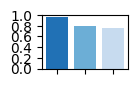

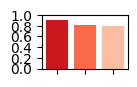


Sensitivity_recall
0	TNF	0.9545
1	LPS	0.8030
5	TNF_LPS	0.7636


Precision
0	TNF	0.9000
1	LPS	0.8179
5	TNF_LPS	0.7975



In [3]:
# pair 1
# TNF - LPS

# Define subset conditions (B)
subset_labels_ligand_pair = [0, 1, 5]  # TNF, LPS, TNF_LPS
# Label mapping for subset B
label_mapping_ligand_pair = {0: 'TNF', 1: 'LPS', 5: 'TNF_LPS'}
data_label_ligand_pair = "TNF_LPS"
auto_download = 0;
RandomForestClassifier_plot_PairLigand(subset_labels_ligand_pair,label_mapping_ligand_pair, data_label_ligand_pair )


X shape: (30990, 6)
y shape: (30990, 1)


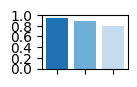

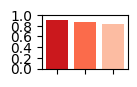


Sensitivity_recall
0	TNF	0.9424
2	CpG	0.8818
6	TNF_CpG	0.7909


Precision
0	TNF	0.9147
2	CpG	0.8635
6	TNF_CpG	0.8339



In [5]:
# pair 2
# Define subset conditions
subset_labels_ligand_pair = [0, 2, 6]  # TNF, CpG, TNF_CpG
# Label mapping for subset
label_mapping_ligand_pair = {0: 'TNF', 2: 'CpG', 6: 'TNF_CpG'}
data_label_ligand_pair = "TNF_CpG"
auto_download = 0;
RandomForestClassifier_plot_PairLigand(subset_labels_ligand_pair,label_mapping_ligand_pair, data_label_ligand_pair )


X shape: (30990, 6)
y shape: (30990, 1)


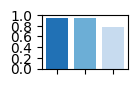

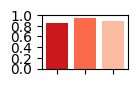


Sensitivity_recall
0	TNF	0.9455
3	PolyIC	0.9515
7	TNF_PolyIC	0.7727


Precision
0	TNF	0.8455
3	PolyIC	0.9401
7	TNF_PolyIC	0.8885



In [6]:
# pair 3
# Define subset conditions
subset_labels_ligand_pair = [0, 3, 7]  # TNF, PolyIC, TNF_PolyIC
# Label mapping for subset
label_mapping_ligand_pair = {0: 'TNF', 3: 'PolyIC', 7: 'TNF_PolyIC'}
data_label_ligand_pair = "TNF_PolyIC"
auto_download = 0;
RandomForestClassifier_plot_PairLigand(subset_labels_ligand_pair,label_mapping_ligand_pair, data_label_ligand_pair )


X shape: (30990, 6)
y shape: (30990, 1)


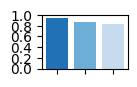

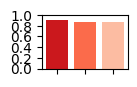


Sensitivity_recall
0	TNF	0.9364
4	Pam3CSK	0.8788
8	TNF_Pam3CSK	0.8333


Precision
0	TNF	0.9088
4	Pam3CSK	0.8735
8	TNF_Pam3CSK	0.8648



In [7]:
# pair 4
# Define subset conditions
subset_labels_ligand_pair = [0, 4, 8]  # TNF, Pam3CSK, TNF_Pam3CSK
# Label mapping for subset
label_mapping_ligand_pair = {0: 'TNF', 4: 'Pam3CSK', 8: 'TNF_Pam3CSK'}
data_label_ligand_pair = "TNF_Pam3CSK"
auto_download = 0;
RandomForestClassifier_plot_PairLigand(subset_labels_ligand_pair,label_mapping_ligand_pair, data_label_ligand_pair )


X shape: (30990, 6)
y shape: (30990, 1)


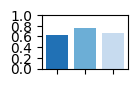

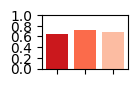


Sensitivity_recall
1	LPS	0.6273
2	CpG	0.7545
9	LPS_CpG	0.6606


Precision
1	LPS	0.6389
2	CpG	0.7217
9	LPS_CpG	0.6791



In [8]:
# pair 5
# Define subset conditions
subset_labels_ligand_pair = [1, 2, 9]  # LPS, CpG, LPS_CpG
# Label mapping for subset
label_mapping_ligand_pair = {1: 'LPS', 2: 'CpG', 9: 'LPS_CpG'}
data_label_ligand_pair = "LPS_CpG"
auto_download = 0;
RandomForestClassifier_plot_PairLigand(subset_labels_ligand_pair,label_mapping_ligand_pair, data_label_ligand_pair )


X shape: (30990, 6)
y shape: (30990, 1)


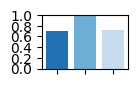

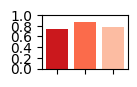


Sensitivity_recall
1	LPS	0.7000
3	PolyIC	0.9727
10	LPS_PolyIC	0.7273


Precision
1	LPS	0.7380
3	PolyIC	0.8747
10	LPS_PolyIC	0.7742



In [9]:
# pair 6
# Define subset conditions
subset_labels_ligand_pair = [1, 3, 10]  # LPS, PolyIC, LPS_PolyIC
# Label mapping for subset
label_mapping_ligand_pair = {1: 'LPS', 3: 'PolyIC', 10: 'LPS_PolyIC'}
data_label_ligand_pair = "LPS_PolyIC"
auto_download = 0;
RandomForestClassifier_plot_PairLigand(subset_labels_ligand_pair,label_mapping_ligand_pair, data_label_ligand_pair )


X shape: (30990, 6)
y shape: (30990, 1)


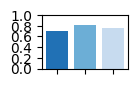

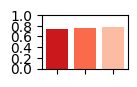


Sensitivity_recall
1	LPS	0.7000
4	Pam3CSK	0.8152
11	LPS_Pam3CSK	0.7515


Precision
1	LPS	0.7333
4	Pam3CSK	0.7535
11	LPS_Pam3CSK	0.7799



In [10]:
# pair 7
# Define subset conditions
subset_labels_ligand_pair = [1, 4, 11]  # LPS, Pam3CSK, LPS_Pam3CSK
# Label mapping for subset
label_mapping_ligand_pair = {1: 'LPS', 4: 'Pam3CSK', 11: 'LPS_Pam3CSK'}
data_label_ligand_pair = "LPS_Pam3CSK"
auto_download = 0;
RandomForestClassifier_plot_PairLigand(subset_labels_ligand_pair,label_mapping_ligand_pair, data_label_ligand_pair )


X shape: (30990, 6)
y shape: (30990, 1)


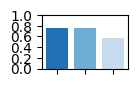

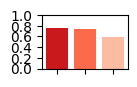


Sensitivity_recall
2	CpG	0.7606
4	PolyIC	0.7667
13	CpG_PolyIC	0.5758


Precision
2	CpG	0.7606
4	PolyIC	0.7398
13	CpG_PolyIC	0.5975



In [11]:
# pair 8
# Define subset conditions
subset_labels_ligand_pair = [2, 3, 12]  # CpG, PolyIC, CpG_PolyIC
# Label mapping for subset
label_mapping_ligand_pair = {2: 'CpG', 4: 'PolyIC', 13: 'CpG_PolyIC'}
data_label_ligand_pair = "CpG_PolyIC"
auto_download = 0;
RandomForestClassifier_plot_PairLigand(subset_labels_ligand_pair,label_mapping_ligand_pair, data_label_ligand_pair )


X shape: (30990, 6)
y shape: (30990, 1)


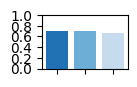

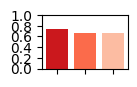


Sensitivity_recall
2	CpG	0.7091
4	Pam3CSK	0.7000
13	CpG_Pam3CSK	0.6606


Precision
2	CpG	0.7405
4	Pam3CSK	0.6696
13	CpG_Pam3CSK	0.6626



In [12]:
# pair 9
# Define subset conditions
subset_labels_ligand_pair = [2, 4, 13]  # CpG, Pam3CSK, CpG_Pam3CSK
# Label mapping for subset
label_mapping_ligand_pair = {2: 'CpG', 4: 'Pam3CSK', 13: 'CpG_Pam3CSK'}
data_label_ligand_pair = "CpG_Pam3CSK"
auto_download = 0;
RandomForestClassifier_plot_PairLigand(subset_labels_ligand_pair,label_mapping_ligand_pair, data_label_ligand_pair )


X shape: (30990, 6)
y shape: (30990, 1)


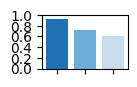

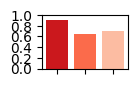


Sensitivity_recall
3	PolyIC	0.9242
4	Pam3CSK	0.7182
14	PolyIC_Pam3CSK	0.6121


Precision
3	PolyIC	0.9077
4	Pam3CSK	0.6493
14	PolyIC_Pam3CSK	0.6990



In [13]:
# pair 10
# Define subset conditions
subset_labels_ligand_pair = [3, 4, 14]  # PolyIC, Pam3CSK, PolyIC_Pam3CSK
# Label mapping for subset
label_mapping_ligand_pair = {3: 'PolyIC', 4: 'Pam3CSK', 14: 'PolyIC_Pam3CSK'}
data_label_ligand_pair = "PolyIC_Pam3CSK"
auto_download = 0;
RandomForestClassifier_plot_PairLigand(subset_labels_ligand_pair,label_mapping_ligand_pair, data_label_ligand_pair )
